 LEVEL 2 - TASK 1: ADVANCED REGRESSION

 Dataset Shape: (506, 14)

 First 5 Rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   IN

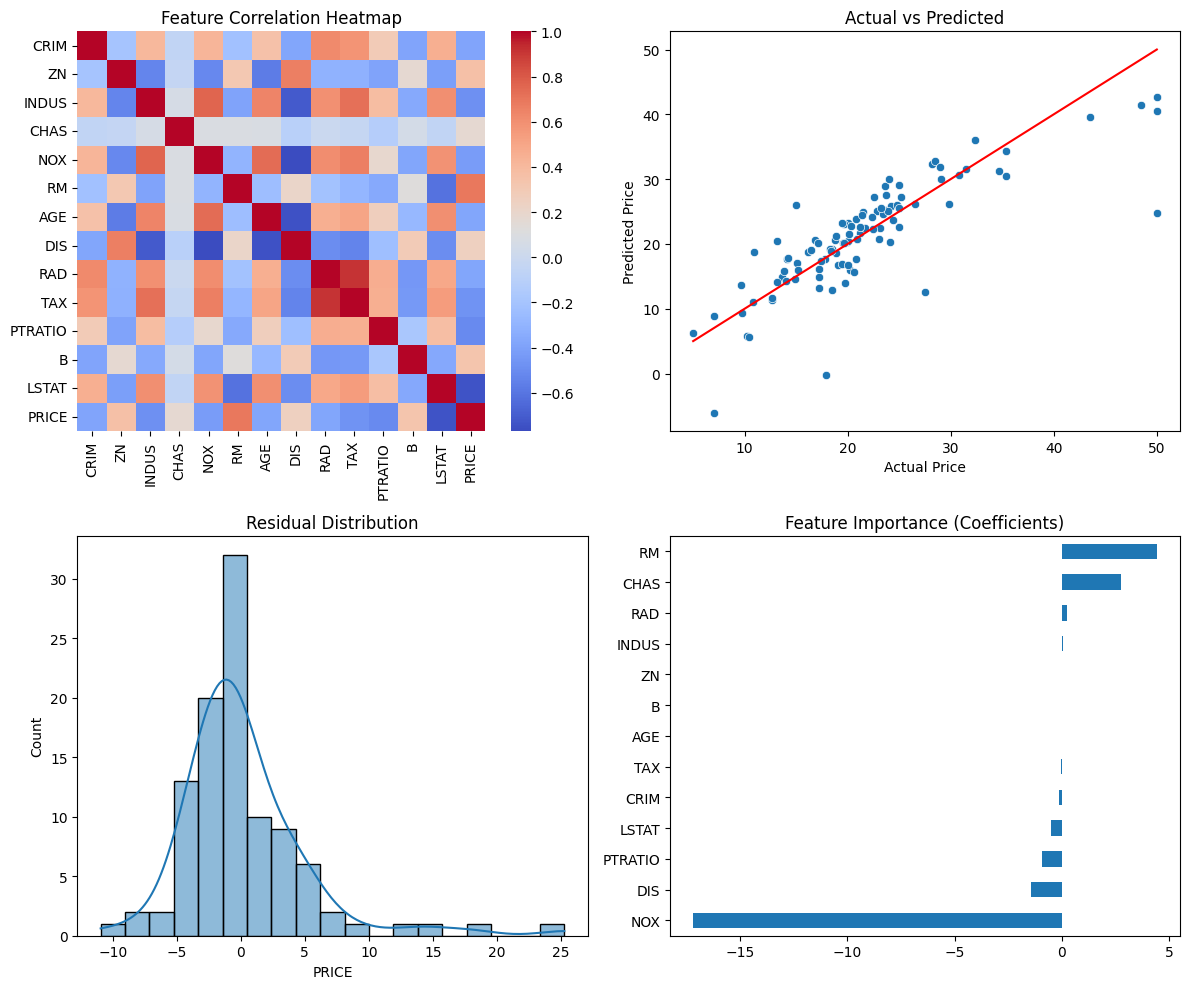


✔ Predictive Modeling (Regression) Completed.


In [ ]:

# LEVEL 2 - TASK 1: ADVANCED REGRESSION PROJECT


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print(" LEVEL 2 - TASK 1: ADVANCED REGRESSION")


# Load Dataset

df = pd.read_csv("../datasets/house Prediction Data Set.csv",
                 sep=r"\s+",
                 header=None,
                 engine="python")

df.columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
              "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"]


# DATA INFORMATION

print("\n Dataset Shape:", df.shape)

print("\n First 5 Rows:")
print(df.head())

print("\n Dataset Info:")
df.info()

print("\n Summary Statistics:")
print(df.describe())


# Model Preparation

X = df.drop("PRICE", axis=1)
y = df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n📊 Model Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


# ADVANCED VISUALIZATIONS


plt.figure(figsize=(12,10))

# 1️⃣ Correlation Heatmap
plt.subplot(2,2,1)
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")

# 2️⃣ Actual vs Predicted with Line
plt.subplot(2,2,2)
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

# 3️⃣ Residual Distribution
plt.subplot(2,2,3)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

# 4️⃣ Feature Importance (Coefficients)
plt.subplot(2,2,4)
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Coefficients)")

plt.tight_layout()
plt.show()

print("\n✔ Predictive Modeling (Regression) Completed.")